### Моделирование БИНС карьерного самосвала БелАЗ-7513

In [2]:
%load_ext autoreload
%autoreload 2
# %matplotlib qt5

import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
REPORT_DIR = PROJECT_ROOT / 'reports'
DATA_DIR   = PROJECT_ROOT / 'generated_data'
MOTION_DIR   = PROJECT_ROOT / 'motion_profiles'

print(f'PROJECT_ROOT: {PROJECT_ROOT}')
print(f'REPORT_DIR: {REPORT_DIR}')
print(f'DATA_DIR: {DATA_DIR}')
print(f'MOTION_DIR: {MOTION_DIR}')


REPORT_DIR.mkdir(exist_ok=True)
DATA_DIR.mkdir(exist_ok=True)
MOTION_DIR.mkdir(exist_ok=True)

# Config libs
from src.config.config import IMU_ERR, GPS_ERR
from src.config.constants import FS_IMU, FS_GPS, INIT_LAT, INIT_LON, INIT_ALT, A_WGS84


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
PROJECT_ROOT: /home/rsadovec/prj/KAMAZ_Jupyter
REPORT_DIR: /home/rsadovec/prj/KAMAZ_Jupyter/reports
DATA_DIR: /home/rsadovec/prj/KAMAZ_Jupyter/generated_data
MOTION_DIR: /home/rsadovec/prj/KAMAZ_Jupyter/motion_profiles


Генерация всех профилей движения

In [ ]:
from src.simulation.motion_generator import generate_all

generate_all(out_dir=MOTION_DIR)

Генерируем сценарий -> IMU, GNSS data

In [3]:
from src.analysis.frames import prepare_scenario

# Сценарии: 01_stationary, 02_acceleration, 03_straight_cruise,
#           04_braking, 05_turn, 06_uphill, 07_downhill_turn,
#           10_accel_cruise_brake, 99_full_mission

S = prepare_scenario('02_acceleration', MOTION_DIR, DATA_DIR, vibration_mode='harmonics_plus_noise')
# S = prepare_scenario('05_turn', MOTION_DIR, DATA_DIR, vibration_mode='harmonics_plus_noise')

imu_time = S['imu_time']
accel = S['accel']
gyro = S['gyro']
accel_vib = S['accel_vib']
gyro_vib = S['gyro_vib']

ref_pos_ned   = S['ref_pos_ned']
ref_vel_ned   = S['ref_vel_ned']
ref_euler_ned = S['ref_euler_ned']
ref_euler_deg = np.rad2deg(S['ref_euler_ned'])

gps_pos_ned=S['gps_pos_ned']
gps_vel_ned=S['gps_vel_ned']
gps_idx=S['gps_idx'] # - на какие индексы ИИМ приходиться GPS
q0=S['q0']
lat0_deg=INIT_LAT,
lat0_rad=np.deg2rad(INIT_LAT)
noise=S['noise']


------------------------------------------------------------
Sample frequency of IMU: [fs] = 400.0 Hz
Reference frame: 0
Simulation time duration: 11.1125 s
Simulation runs: 1

------------------------------------------------------------
Simulation results are saved to /home/rsadovec/prj/KAMAZ_Jupyter/generated_data/02_acceleration
The following results are saved:
	time: sample time
	ref_pos: true LLA pos in the navigation frame
	ref_vel: true vel in the NED frame
	ref_att_euler: true attitude (Euler angles, ZYX)
	ref_accel: true accel in the body frame
	ref_gyro: true angular velocity in the body frame
	gps_time: GPS sample time
	ref_gps: true GPS LLA position and NED velocity
	gps_visibility: GPS visibility
	accel: accel measurements
	gyro: gyro measurements
	gps: GPS LLA position and NED velocity measurements
	ref_att_quat: true attitude (quaternion)



In [ ]:
from src.analysis.visualization import plot_accel_signal, plot_gyro_signal

_ =plot_accel_signal(imu_time, accel, ' (без вибраций)',
                  save_dir=f'{REPORT_DIR}/raw')
_ = plot_gyro_signal(imu_time, gyro, ' (без вибраций)',
                 save_dir=f'{REPORT_DIR}/raw')

# _ = plot_accel_signal(S['imu_time'], S['accel_vib'], ' (с вибрациями ДВС)',
#                   save_dir=f'{REPORT_DIR}/with_vib')
# _ = plot_gyro_signal(S['imu_time'], S['gyro_vib'], ' (с вибрациями ДВС)',
#                  save_dir=f'{REPORT_DIR}/with_vib')

In [ ]:
from src.analysis.visualization import plot_psd, plot_spectrogram_2d, plot_spectrogram_3d

plot_psd(imu_time, accel, fs=400,
         sensor_name='Акселерометр', units='м/с²',
         save_dir=f'{REPORT_DIR}/raw', fname='psd_accel')
_ = plot_psd(imu_time, gyro, fs=400,
         sensor_name='Гироскоп', units='рад/с',
         save_dir=f'{REPORT_DIR}/raw', fname='psd_gyro')

# plot_psd(imu_time, accel_vib, fs=400,
#          sensor_name='Акселерометр', units='м/с²',
#          save_dir=REPORT_DIR, fname='psd_accel')
# _ = plot_psd(imu_time, gyro_vib, fs=400,
#          sensor_name='Гироскоп', units='рад/с',
#          save_dir=REPORT_DIR, fname='psd_gyro')

# Спектрограмма Z-оси акселерометра (там вибрация самая сильная)
# _ = plot_spectrogram_2d(imu_time, accel_vib[:, 2], fs=400,
#                     channel_name='Z', sensor_name='Акселерометр',
#                     save_dir=REPORT_DIR)
# _ = plot_spectrogram_3d(imu_time, accel_vib[:, 2], fs=400,
#                     channel_name='Z', sensor_name='акселерометра',
#                     save_dir=REPORT_DIR)

Девиация Аллана (не работает)

In [ ]:
# from src.analysis.visualization import
# from visualization import load_data, plot_allan_simulated

# sim_Allan = test_allan('generated_data/90_AllanDev')
# data_Allan = load_data('generated_data/90_AllanDev')

# plot_allan_simulated(data_Allan['gyro'], data_Allan['accel'], fs=400,
#                      save_dir=REPORT_DIR)

Глава 1) Оценка ориентации

Фильтр Маджвика

In [4]:
from src.navigation.sins import make_sins
from src.analysis.visualization import plot_trajectory_3d, plot_velocity_ned, plot_euler_angles, plot_position_error, plot_attitude_error

sins_madg = make_sins('madgwick', fs=400.0, beta=0.03,
                      init_pos_ned=ref_pos_ned[0],
                      init_vel_ned=ref_vel_ned[0],
                      init_quat=q0, 
                      lat0_deg=lat0_deg
                     )

# out_madg = sins_madg.run(accel_vib, gyro_vib)
out_madg = sins_madg.run(accel, gyro)

_ = plot_trajectory_3d(ref_pos_ned, out_madg['p_n'], save_dir=f'{REPORT_DIR}/madgwick')
# _ = plot_velocity_ned(imu_time, ref_vel_ned, out_madg['v_n'], save_dir=f'{REPORT_DIR}/madgwick')
# _ = plot_euler_angles(imu_time, ref_euler_ned, out_madg['euler'], save_dir=f'{REPORT_DIR}/madgwick')
# _ = plot_position_error(imu_time, out_madg['p_n'], ref_pos_ned, save_dir=f'{REPORT_DIR}/madgwick')
# _ = plot_attitude_error(imu_time, out_madg['euler'], ref_euler_ned, save_dir=f'{REPORT_DIR}/madgwick')

ValueError: setting an array element with a sequence. The requested array has an inhomogeneous shape after 1 dimensions. The detected shape was (3,) + inhomogeneous part.

БИНС с фильтром Махони

In [ ]:
from src.navigation.sins import make_sins
from src.analysis.visualization import plot_trajectory_3d, plot_velocity_ned, plot_euler_angles, plot_position_error, plot_attitude_error

sins_mah = make_sins('mahony', fs=400.0, k_P=0.1, k_I=0.001,
                     init_pos_ned=ref_pos_ned[0],
                     init_vel_ned=ref_vel_ned[0],
                     init_quat=q0, 
                     lat0_deg=lat0_deg
                     )

# out_mah = sins_mah.run(accel_vib, gyro_vib)
out_mah = sins_mah.run(accel, gyro)

_ = plot_trajectory_3d(ref_pos_ned, out_mah['p_n'], save_dir=f'{REPORT_DIR}/mahony')
# _ = plot_velocity_ned(imu_time, ref_vel_ned, v_h, save_dir=f'{REPORT_DIR}/mahony')
# _ = plot_euler_angles(imu_time, ref_euler_ned, eul_h, save_dir=f'{REPORT_DIR}/mahony')
# _ = plot_position_error(imu_time, p_h, ref_pos_ned, save_dir=f'{REPORT_DIR}/mahony')
# _ = plot_attitude_error(imu_time, eul_h, ref_euler_ned, save_dir=f'{REPORT_DIR}/mahony')

Анализ β для фильтра Маджвика

In [ ]:
from src.analysis.visualization import plot_beta_sweep

# beta_values = [0.005, 0.02, 0.05, 0.1, 0.3, 1.0]
beta_values = [1, 0.25, 0.1, 0.05, 0.02, 0.005]
beta_results = {}

for b in beta_values:
   
    sins_b = make_sins('madgwick', fs=400.0, beta=b,
                       init_pos_ned=ref_pos_ned[0],
                       init_vel_ned=ref_vel_ned[0],
                       init_quat=q0, 
                       lat0_deg=lat0_deg
                       )
    
    _, _, _, eul_b = sins_b.run(accel_vib, gyro_vib)
    beta_results[b] = eul_b
    print(f"  β = {b:.3f} готово")

plot_beta_sweep(imu_time, beta_results, ref_euler_ned,
                save_dir=f'{REPORT_DIR}/beta_sweep')

Глава 2) Схемы комплексирования БИНС/ГНСС

EKF

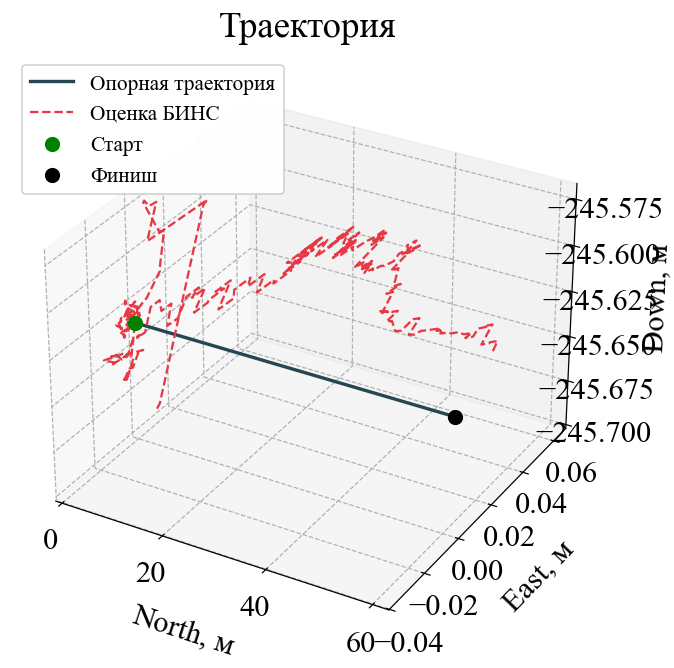

In [5]:
from src.navigation.ekf import InsGnssEKF
from src.analysis.visualization import plot_trajectory_3d, plot_velocity_ned, plot_euler_angles, plot_position_error, plot_attitude_error

ekf = InsGnssEKF(
    fs_imu=400.0, fs_gps=10.0,
    sigma_a_n=noise['sigma_a_n'], 
    sigma_g_n=noise['sigma_g_n'],
    sigma_ba=noise['sigma_ba'], 
    sigma_bg=noise['sigma_bg'],
    sigma_gps_pos=noise['sigma_gps_pos'], 
    sigma_gps_vel=noise['sigma_gps_vel'],
    init_r=ref_pos_ned[0], 
    init_v=ref_vel_ned[0],
    init_q=q0,
)

N = len(imu_time)
p_ekf, v_ekf, eul_ekf = np.zeros((N, 3)), np.zeros((N, 3)), np.zeros((N, 3))

g_ptr = 0
for k in range(N):
    ekf.predict(accel[k], gyro[k])
    if g_ptr < len(gps_idx) and k == gps_idx[g_ptr]:
        ekf.update_gnss(gps_pos_ned[g_ptr], gps_vel_ned[g_ptr])
        g_ptr += 1
    p_ekf[k]   = ekf.r
    v_ekf[k]   = ekf.v
    eul_ekf[k] = ekf.euler_zyx_deg

_ = plot_trajectory_3d(ref_pos_ned, p_ekf, save_dir=f'{REPORT_DIR}/ekf')
# _ = plot_velocity_ned(imu_time, ref_vel_ned, v_ekf, save_dir=f'{REPORT_DIR}/ekf')
# _ = plot_euler_angles(imu_time, ref_euler_ned, eul_ekf, save_dir=f'{REPORT_DIR}/ekf')
# _ = plot_position_error(imu_time, p_ekf, ref_pos_ned, save_dir=f'{REPORT_DIR}/ekf')
# _ = plot_attitude_error(imu_time, eul_ekf, ref_euler_ned, save_dir=f'{REPORT_DIR}/ekf')

UKF

In [ ]:
from src.navigation.ukf import InsGnssUKF
from src.analysis.visualization import plot_trajectory_3d, plot_velocity_ned, plot_euler_angles, plot_position_error, plot_attitude_error

ukf = InsGnssUKF(
    fs_imu=400.0, fs_gps=10.0,
    sigma_a_n=noise['sigma_a_n'], 
    sigma_g_n=noise['sigma_g_n'],
    sigma_ba=noise['sigma_ba'], 
    sigma_bg=noise['sigma_bg'],
    sigma_gps_pos=noise['sigma_gps_pos'], 
    sigma_gps_vel=noise['sigma_gps_vel'],
    init_r=ref_pos_ned[0], 
    init_v=ref_vel_ned[0],
    init_q=q0,
)

N = len(imu_time)
p_ukf, v_ukf, eul_ukf = np.zeros((N, 3)), np.zeros((N, 3)), np.zeros((N, 3))

g_ptr = 0
for k in range(N):
    ukf.predict(accel[k], gyro[k])
    if g_ptr < len(gps_idx) and k == gps_idx[g_ptr]:
        ukf.update_gnss(gps_pos_ned[g_ptr], gps_vel_ned[g_ptr])
        g_ptr += 1
    p_ukf[k]   = ukf.r
    v_ukf[k]   = ukf.v
    eul_ukf[k] = ukf.euler_zyx_deg
         
_ = plot_trajectory_3d(ref_pos_ned, p_ukf, save_dir=f'{REPORT_DIR}/ukf')
# _ = plot_velocity_ned(imu_time, ref_vel_ned, v_ekf, save_dir=f'{REPORT_DIR}/ukf')
# _ = plot_euler_angles(imu_time, ref_euler_ned, eul_ekf, save_dir=f'{REPORT_DIR}/ukf')
# _ = plot_position_error(imu_time, p_ekf, ref_pos_ned, save_dir=f'{REPORT_DIR}/ukf')
# _ = plot_attitude_error(imu_time, eul_ekf, ref_euler_ned, save_dir=f'{REPORT_DIR}/ukf')

FGO

/home/rsadovec/prj/KAMAZ_Jupyter/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:710: RuntimeWarning: divide by zero encountered in divide
  slope = (y_hi - y_lo) / (x_hi - x_lo)[:, None]
/home/rsadovec/prj/KAMAZ_Jupyter/.venv/lib/python3.11/site-packages/scipy/interpolate/_interpolate.py:713: RuntimeWarning: invalid value encountered in multiply
  y_new = slope*(x_new - x_lo)[:, None] + y_lo


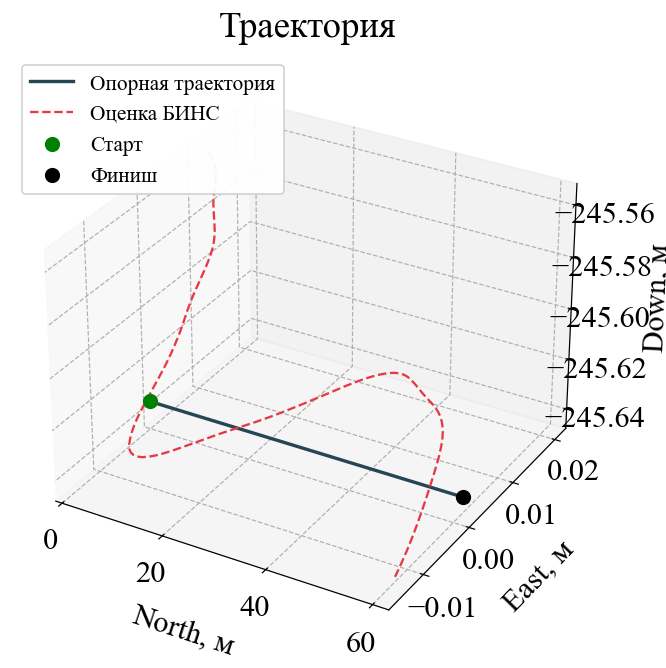

In [7]:
import gtsam
from gtsam import Pose3, Rot3, Point3
from src.navigation.fgo import InsGnssFGO
from scipy.interpolate import interp1d
from src.analysis.visualization import plot_trajectory_3d, plot_velocity_ned, plot_euler_angles, plot_position_error, plot_attitude_error

w, x, y, z = q0
init_rot = Rot3.Quaternion(w, x, y, z)          
init_pos = Point3(INIT_LAT,INIT_LON,INIT_ALT,)         
init_pose = Pose3(init_rot, init_pos)

fgo = InsGnssFGO(
    fs_imu=400.0,
    sigma_a_n=noise['sigma_a_n'], 
    sigma_g_n=noise['sigma_g_n'],
    sigma_ba=noise['sigma_ba'], 
    sigma_bg=noise['sigma_bg'],
    sigma_gps_pos=noise['sigma_gps_pos'],
    init_pose=init_pose, 
    init_vel=ref_vel_ned[0],
)

N = len(imu_time)
g_ptr = 0
node_t = [imu_time[0]]              # время узлов графа (старт + эпохи GNSS)

for k in range(N):
    fgo.integrate(accel[k], gyro[k])      # копим IMU в предынтегратор
    if g_ptr < len(gps_idx) and k == gps_idx[g_ptr]:
        fgo.add_gnss(gps_pos_ned[g_ptr])       # новый узел + GNSS-фактор
        node_t.append(imu_time[k])
        g_ptr += 1

# Решаем граф ОДИН раз в конце
p_nodes, v_nodes, eul_nodes = fgo.optimize()
node_t = np.array(node_t)

# Приводим сетку к инерциалке
def to_imu_grid(arr_nodes, t_nodes, t_imu):
    f = interp1d(t_nodes, arr_nodes, axis=0,
                 fill_value='extrapolate', bounds_error=False)
    return f(t_imu)

# def to_imu_grid(arr_nodes, t_nodes, t_imu):
#     f = interp1d(t_nodes, arr_nodes, axis=0,
#                  bounds_error=False,
#                  fill_value=(arr_nodes[0], arr_nodes[-1]))  # ← кортеж: лево/право
#     return f(t_imu)

p_fgo   = to_imu_grid(p_nodes,   node_t, imu_time)
v_fgo   = to_imu_grid(v_nodes,   node_t, imu_time)
eul_fgo = to_imu_grid(eul_nodes, node_t, imu_time)   

_ = plot_trajectory_3d(ref_pos_ned, p_fgo, save_dir=f'{REPORT_DIR}/fgo')
# _ = plot_velocity_ned(imu_time, ref_vel_ned, v_fgo, save_dir=f'{REPORT_DIR}/fgo')
# _ = plot_euler_angles(imu_time, ref_euler_ned, eul_fgo, save_dir=f'{REPORT_DIR}/fgo')
# _ = plot_position_error(imu_time, p_fgo, ref_pos_ned, save_dir=f'{REPORT_DIR}/fgo')
# _ = plot_attitude_error(imu_time, eul_fgo, ref_euler_deg, save_dir=f'{REPORT_DIR}/fgo')

In [8]:
print("nan в p_fgo:", np.isnan(p_fgo).any(), "| сколько:", np.isnan(p_fgo).sum())
print("node_t[0]:", node_t[0], " imu_time[0]:", S['imu_time'][0])
print("node_t[-1]:", node_t[-1], " imu_time[-1]:", S['imu_time'][-1])

nan в p_fgo: True | сколько: 3
node_t[0]: 0.0  imu_time[0]: 0.0
node_t[-1]: 11.1  imu_time[-1]: 11.11


Глава 3) Сравниваем

In [9]:
from src.analysis.metrics import print_comparison

results = {
    'EKF':   {'pos': p_ekf,  'vel': v_ekf,  'euler': eul_ekf},
    'UKF':   {'pos': p_ukf,  'vel': v_ukf,  'euler': eul_ukf},
    'FGO':   {'pos': p_fgo,  'vel': v_fgo,  'euler': eul_fgo},
}
print_comparison(results, ref_pos_ned, ref_vel_ned, ref_euler_deg)

NameError: name 'p_ukf' is not defined

In [10]:
_ =plot_overlay_trajectory(ref_pos_ned, p_ekf, p_ukf, p_fgo,
                        save_dir=f'{REPORT_DIR}/compare/trajectory.png')
_ = plot_overlay_error(S['imu_time'], ref_pos_ned,
                   {'EKF': p_ekf, 'UKF': p_ukf, 'FGO': p_fgo},
                   save_dir=f'{REPORT_DIR}/compare/error.png')

NameError: name 'plot_overlay_trajectory' is not defined